# Compare orbit solutions — daily

Compares two orbit solutions (GOP and SSA) day by day in the RTN frame
using Hermite interpolation. Produces daily statistics, epoch-wise
difference series, periodograms, and summary plots.

## Imports

Load standard library modules, third-party packages, and functions from the local `doris` package.

In [1]:
# --- Standard library ---
import sys
from pathlib import Path
from datetime import date

# --- Third-party packages ---
try:
    import numpy as np
except ImportError as e:
    raise RuntimeError("Missing dependency: numpy. Install with: pip install numpy") from e

try:
    import pandas as pd
    pd.set_option("display.float_format", "{:.5f}".format)
except ImportError as e:
    raise RuntimeError("Missing dependency: pandas. Install with: pip install pandas") from e

try:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt
except ImportError as e:
    raise RuntimeError("Missing dependency: matplotlib. Install with: pip install matplotlib") from e

try:
    from doris.analysis.orbits import (
        compare_trajectories,
        iter_orbit_days,
        load_orbit_day,
        orbit_diff_stats,
        orbit_diff_summary,
    )
    from doris.analysis.orbits.loading import select_file_for_day
    from doris.analysis.spectral.periodogram import compute_periodogram
    from doris.output.tables import save_latex_table, Col
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from the expected directory."
    ) from e


## Paths and parameters

Set the satellite, solutions being compared, processing interval, and output locations.

In [2]:
# --- Dataset selection ---
satellite = "srl"

# --- Solutions ---
REFERENCE_SOLUTION = "gop"
COMPARED_SOLUTION  = "ssa"
SOLUTION_TAG       = f"{REFERENCE_SOLUTION}_vs_{COMPARED_SOLUTION}"

# --- Project paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_ROOT    = PROJECT_ROOT / "data"

GOP_ROOT    = DATA_ROOT / "orbits" / REFERENCE_SOLUTION / satellite
SSA_ROOT    = DATA_ROOT / "orbits" / COMPARED_SOLUTION  / satellite
RESULTS_DIR = DATA_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "results" / "satellites" / "hermite" / satellite
TABLES_DIR  = PROJECT_ROOT / "LaTeX" / "tables" / "results" / "satellites" / "hermite" / satellite

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Processing settings ---
START_DATE     = date(2024, 1, 1)
END_DATE       = date(2024, 1, 30)
HERMITE_DEGREE = 11
EDGE_TRIM      = 6

# --- Display labels for plots ---
_sat_display = satellite.upper()
_sol_display = "GOP–SSA"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GOP_ROOT:    ", GOP_ROOT)
print("SSA_ROOT:    ", SSA_ROOT)
print("FIGURES_DIR: ", FIGURES_DIR)
print("TABLES_DIR:  ", TABLES_DIR)
print("RESULTS_DIR: ", RESULTS_DIR)
print("satellite:   ", satellite, "(", _sat_display, ")")


PROJECT_ROOT: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
GOP_ROOT:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\orbits\gop\srl
SSA_ROOT:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\orbits\ssa\srl
FIGURES_DIR:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl
TABLES_DIR:   C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\satellites\hermite\srl
RESULTS_DIR:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results
satellite:    srl ( SRL )


## Daily processing loop

Load matching GOP and SSA orbit days, compare trajectories in RTN, and store daily differences.

In [3]:
results: dict[date, pd.DataFrame] = {}

for day, gop_df in iter_orbit_days(GOP_ROOT, START_DATE, END_DATE):
    ssa_info = select_file_for_day(SSA_ROOT, day)
    if ssa_info is None:
        continue

    ssa_df = load_orbit_day(SSA_ROOT, day, window=0.5)

    t0 = gop_df["MJD_TAI"].iloc[0]
    gop_df["t_sec"] = (gop_df["MJD_TAI"] - t0) * 86400.0
    ssa_df["t_sec"] = (ssa_df["MJD_TAI"] - t0) * 86400.0

    diff = compare_trajectories(
        ssa_df,
        gop_df,
        time_col="t_sec",
        degree=HERMITE_DEGREE,
        edge_trim=EDGE_TRIM,
        rtn=True,
        unit="m",
    )
    results[day] = diff

print(f"Processed days: {len(results)}")


Processed days: 30


## Daily statistics

Summarize the daily RTN differences for plotting and export.

In [4]:
df_stats = orbit_diff_summary(results)
display(df_stats)

,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0
0,2024-01-01,0.00095,-0.00007,-0.00005,0.00694,0.01717,0.01484,0.00688,0.01717,0.01484
1,2024-01-02,-0.00003,-0.00217,-0.00037,0.00798,0.01781,0.01820,0.00798,0.01768,0.01820
2,2024-01-03,-0.00025,-0.00419,-0.00059,0.00836,0.01968,0.02061,0.00836,0.01922,0.02060
3,2024-01-04,-0.00042,-0.00334,-0.00110,0.00768,0.02051,0.03507,0.00767,0.02023,0.03505
4,2024-01-05,-0.00015,-0.00273,-0.00007,0.00711,0.01716,0.01970,0.00711,0.01694,0.01970
5,2024-01-06,-0.00016,-0.00312,-0.00068,0.00699,0.01759,0.01949,0.00699,0.01731,0.01948
6,2024-01-07,0.00032,0.00160,-0.00076,0.00692,0.01676,0.02185,0.00692,0.01669,0.02184
7,2024-01-08,0.00068,-0.00308,-0.00077,0.00857,0.02014,0.02512,0.00855,0.01990,0.02510
8,2024-01-09,0.00057,-0.00677,-0.00112,0.00749,0.02023,0.01707,0.00747,0.01906,0.01703
9,2024-01-10,0.00296,-0.00059,-0.00141,0.01125,0.02919,0.01924,0.01085,0.02918,0.01919


## Export

Write summary statistics to CSV. Parquet per-day exports are shown as commented examples.

In [5]:
# Optional export of one parquet file per processed day.
# (RESULTS_DIR / "diffs").mkdir(exist_ok=True)
# for day, diff in sorted(results.items()):
#     out = diff.copy()
#     out.insert(0, "day", day)
#     out.to_parquet(RESULTS_DIR / "diffs" / f"{SOLUTION_TAG}_{satellite}_{day.isoformat()}.parquet", index=False)
# pd.read_parquet(RESULTS_DIR / "diffs" / f"{SOLUTION_TAG}_{satellite}_2024-01-01.parquet")

stats_path = RESULTS_DIR / f"stats_{SOLUTION_TAG}_{satellite}.csv"
df_stats.to_csv(stats_path, index=False)
print("Saved:", stats_path.resolve())

pd.read_csv(stats_path)


Saved: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\stats_gop_vs_ssa_srl.csv


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0
0,2024-01-01,0.00095,-0.00007,-0.00005,0.00694,0.01717,0.01484,0.00688,0.01717,0.01484
1,2024-01-02,-0.00003,-0.00217,-0.00037,0.00798,0.01781,0.01820,0.00798,0.01768,0.01820
2,2024-01-03,-0.00025,-0.00419,-0.00059,0.00836,0.01968,0.02061,0.00836,0.01922,0.02060
3,2024-01-04,-0.00042,-0.00334,-0.00110,0.00768,0.02051,0.03507,0.00767,0.02023,0.03505
4,2024-01-05,-0.00015,-0.00273,-0.00007,0.00711,0.01716,0.01970,0.00711,0.01694,0.01970
5,2024-01-06,-0.00016,-0.00312,-0.00068,0.00699,0.01759,0.01949,0.00699,0.01731,0.01948
6,2024-01-07,0.00032,0.00160,-0.00076,0.00692,0.01676,0.02185,0.00692,0.01669,0.02184
7,2024-01-08,0.00068,-0.00308,-0.00077,0.00857,0.02014,0.02512,0.00855,0.01990,0.02510
8,2024-01-09,0.00057,-0.00677,-0.00112,0.00749,0.02023,0.01707,0.00747,0.01906,0.01703
9,2024-01-10,0.00296,-0.00059,-0.00141,0.01125,0.02919,0.01924,0.01085,0.02918,0.01919


## Prepare plot data

Filter to one interpolation interval (if multiple are present) and compute combined 3D metrics.

In [6]:
plot_df = df_stats.copy()

# Select one interpolation interval if the notebook contains multiple intervals.
if "interval_s" in plot_df.columns:
    SELECT_INTERVAL_S = 600
    plot_df = plot_df[plot_df["interval_s"] == SELECT_INTERVAL_S].copy()

plot_df = plot_df.sort_values("day").reset_index(drop=True)

# Compute combined 3D metrics from the RTN components.
plot_df["3D_mean"] = np.sqrt(
    plot_df["R_mean"]**2 +
    plot_df["T_mean"]**2 +
    plot_df["N_mean"]**2
)
plot_df["3D_rms"] = np.sqrt(
    plot_df["R_rms"]**2 +
    plot_df["T_rms"]**2 +
    plot_df["N_rms"]**2
)
plot_df["3D_rms0"] = np.sqrt(
    plot_df["R_rms0"]**2 +
    plot_df["T_rms0"]**2 +
    plot_df["N_rms0"]**2
)

plot_df


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0,3D_mean,3D_rms,3D_rms0
0,2024-01-01,0.00095,-0.00007,-0.00005,0.00694,0.01717,0.01484,0.00688,0.01717,0.01484,0.00095,0.02373,0.02371
1,2024-01-02,-0.00003,-0.00217,-0.00037,0.00798,0.01781,0.01820,0.00798,0.01768,0.01820,0.00221,0.02669,0.02660
2,2024-01-03,-0.00025,-0.00419,-0.00059,0.00836,0.01968,0.02061,0.00836,0.01922,0.02060,0.00424,0.02970,0.02939
3,2024-01-04,-0.00042,-0.00334,-0.00110,0.00768,0.02051,0.03507,0.00767,0.02023,0.03505,0.00354,0.04134,0.04119
4,2024-01-05,-0.00015,-0.00273,-0.00007,0.00711,0.01716,0.01970,0.00711,0.01694,0.01970,0.00274,0.02708,0.02694
5,2024-01-06,-0.00016,-0.00312,-0.00068,0.00699,0.01759,0.01949,0.00699,0.01731,0.01948,0.00320,0.02717,0.02698
6,2024-01-07,0.00032,0.00160,-0.00076,0.00692,0.01676,0.02185,0.00692,0.01669,0.02184,0.00180,0.02840,0.02834
7,2024-01-08,0.00068,-0.00308,-0.00077,0.00857,0.02014,0.02512,0.00855,0.01990,0.02510,0.00325,0.03331,0.03315
8,2024-01-09,0.00057,-0.00677,-0.00112,0.00749,0.02023,0.01707,0.00747,0.01906,0.01703,0.00688,0.02751,0.02663
9,2024-01-10,0.00296,-0.00059,-0.00141,0.01125,0.02919,0.01924,0.01085,0.02918,0.01919,0.00333,0.03672,0.03657


## Select epoch-wise series

Build a clean epoch-wise dataframe for single-day or multi-day plots.

`DAY_RANGE` uses 1-based indexes in the sorted processed-day list:
- `[1]` — first day only
- `[22]` — day number 22 only
- `[1, 30]` — days 1 through 30
- `None` — whole processed period

In [7]:
DAY_RANGE = [1]

items = sorted(results.items())

if DAY_RANGE is not None:
    start_idx = DAY_RANGE[0] - 1
    end_idx   = DAY_RANGE[-1]
    items     = items[start_idx:end_idx]

clean_days = [day for day, _ in items]
frames = []

for day, df in items:
    df = df.copy()
    epoch_datetime = (
        pd.to_datetime(str(day)) +
        pd.to_timedelta(df["t_sec"], unit="s")
    ).dt.round("1s")
    frames.append(pd.DataFrame({
        "epoch_datetime": epoch_datetime,
        "dR":  df["dR_m"]   * 1000.0,
        "dT":  df["dT_m"]   * 1000.0,
        "dN":  df["dN_m"]   * 1000.0,
        "d3D": df["norm_m"] * 1000.0,
    }))

clean_df = (
    pd.concat(frames, ignore_index=True)
    .dropna()
    .sort_values("epoch_datetime")
    .reset_index(drop=True)
)

# Basic sampling diagnostics.
dt = clean_df["epoch_datetime"].diff().dt.total_seconds()
gaps = dt[dt > dt.median() * 2]
print(f"Rows in clean_df : {len(clean_df)}")
print(f"From             : {clean_df['epoch_datetime'].min()}")
print(f"To               : {clean_df['epoch_datetime'].max()}")
print(f"Step [s]         : median={dt.median():.0f}, max={dt.max():.0f}, min={dt.min():.1f}")
print(f"Gaps > 2x step   : {len(gaps)}")

# DOY label for CSV filename.
_start_doy = min(clean_days).timetuple().tm_yday
_end_doy   = max(clean_days).timetuple().tm_yday
_doy_str   = f"doy{_start_doy:03d}" if _start_doy == _end_doy else f"doy{_start_doy:03d}-doy{_end_doy:03d}"

csv_path = RESULTS_DIR / f"clean_df_{SOLUTION_TAG}_{satellite}_{_doy_str}.csv"
clean_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path.resolve()}")

display(clean_df)


Rows in clean_df : 1440
From             : 2024-01-01 00:00:00
To               : 2024-01-01 23:59:00
Step [s]         : median=60, max=60, min=60.0
Gaps > 2x step   : 0

Saved: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\clean_df_gop_vs_ssa_srl_doy001.csv


,epoch_datetime,dR,dT,dN,d3D
0,2024-01-01 00:00:00,9.74893,-10.05009,-16.38883,21.55550
1,2024-01-01 00:01:00,8.78818,-9.41480,-15.57220,20.20802
2,2024-01-01 00:02:00,8.36857,-14.93928,-13.40081,21.74389
3,2024-01-01 00:03:00,7.88395,-14.74306,-12.14393,20.66372
4,2024-01-01 00:04:00,7.94018,-12.62179,-10.41728,18.18999
...,...,...,...,...,...
1435,2024-01-01 23:55:00,25.38179,-86.48464,-1.88152,90.15191
1436,2024-01-01 23:56:00,24.74412,-88.95618,-0.79755,92.33694
1437,2024-01-01 23:57:00,23.49793,-90.24382,-0.61405,93.25490
1438,2024-01-01 23:58:00,23.30698,-94.26719,0.91358,97.11000


## RTN differences — time series

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001_rtn_differences  [.pdf + .png]


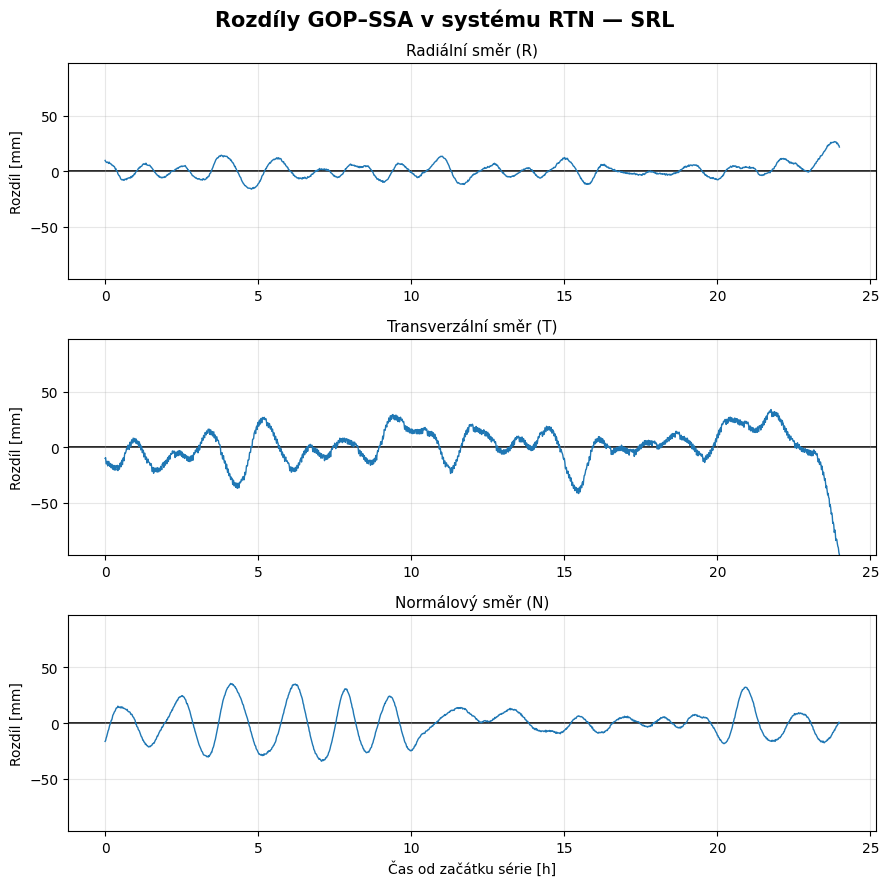

In [8]:
df = clean_df.copy()
t_hours = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds() / 3600.0

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["dR", "dT", "dN"]].values))
ylim = (-max_abs - 0.5, max_abs + 0.5)

for ax, (col, title) in zip(axes, components):
    ax.plot(t_hours, df[col].values, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=1.2, zorder=0)
    ax.set_ylabel("Rozdíl [mm]")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(ylim)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Čas od začátku série [h]")
fig.suptitle(f"Rozdíly {_sol_display} v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_differences"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN differences — histogram

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001_rtn_histogram  [.pdf + .png]


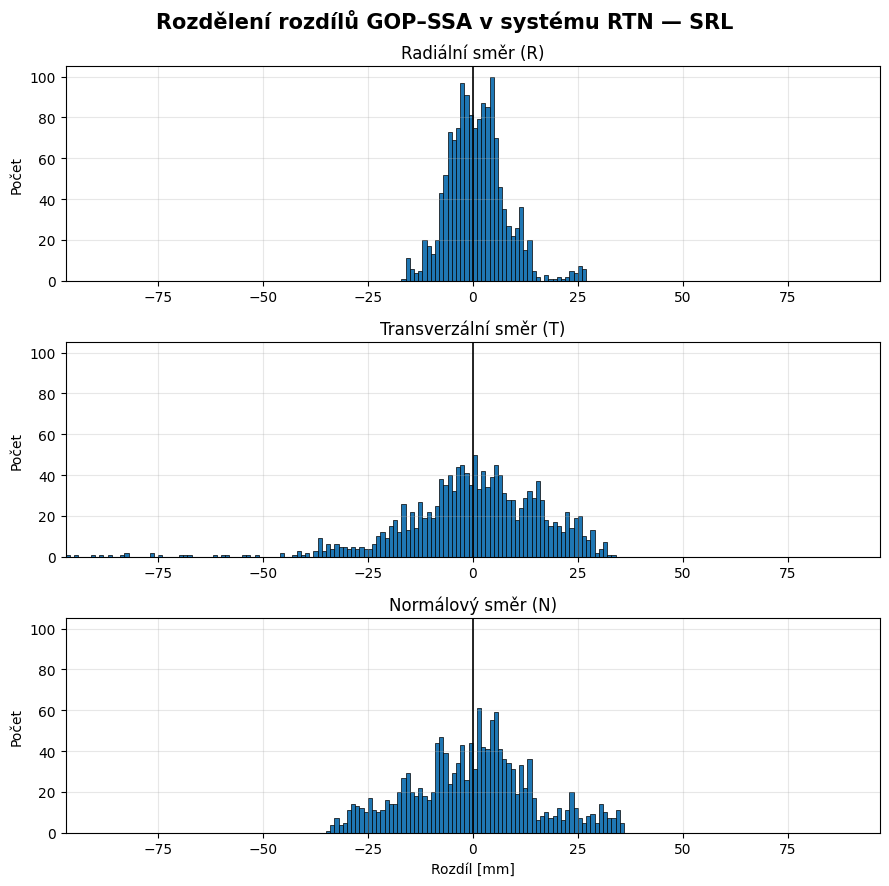

In [9]:
df = clean_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["dR", "dT", "dN"]].values))
xmax = np.ceil(max_abs)
bins = np.arange(-xmax, xmax + 1, 1)

for ax, (col, title) in zip(axes, components):
    ax.hist(df[col].values, bins=bins, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_ylabel("Počet")
    ax.set_title(title)
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Rozdíl [mm]")
fig.suptitle(f"Rozdělení rozdílů {_sol_display} v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_histogram"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN periodogram — Lomb-Scargle

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001_rtn_periodograms_lomb_scargle  [.pdf + .png]


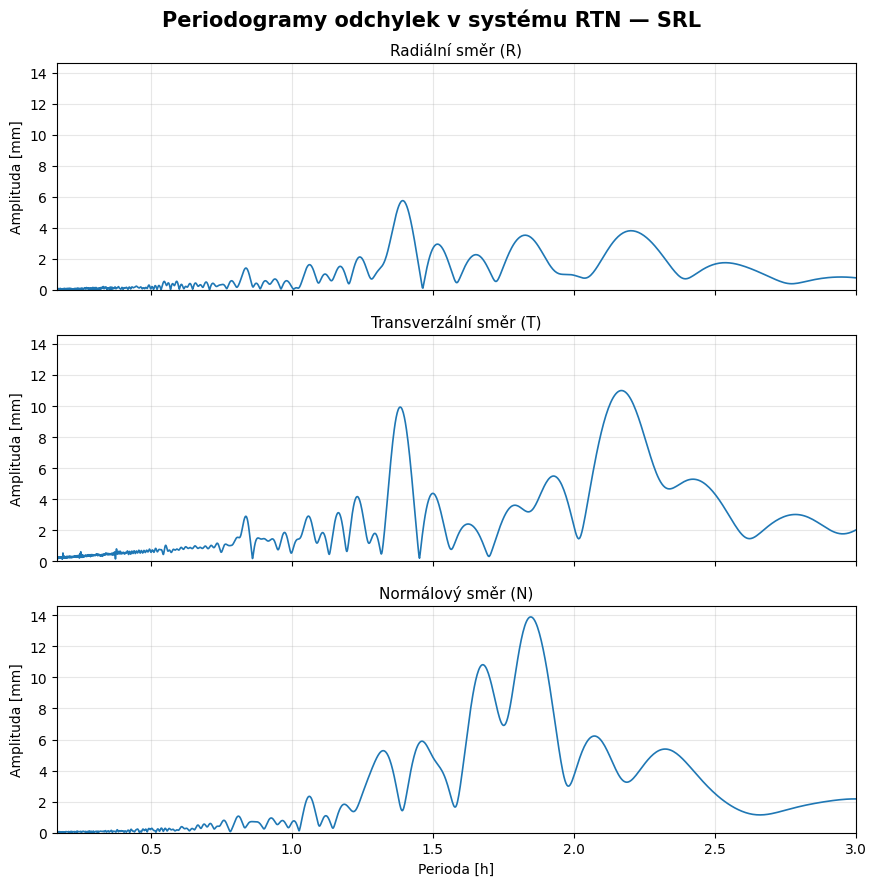

In [10]:
df = clean_df.copy()

t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

MIN_PERIOD_S = 10 * 60
MAX_PERIOD_S = 3 * 3600

periodograms = {}
global_max = 0

for col, _ in components:
    pgram = compute_periodogram(
        t, df[col].values,
        method="lomb_scargle",
        min_period=MIN_PERIOD_S,
        max_period=MAX_PERIOD_S,
    )
    periodograms[col] = pgram
    local_max = pgram.loc[pgram["period"] / 3600 > 0.5, "amplitude"].max()
    if local_max > global_max:
        global_max = local_max

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, (col, title) in zip(axes, components):
    pgram = periodograms[col]
    periods_h = pgram["period"] / 3600
    ax.plot(periods_h, pgram["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(MIN_PERIOD_S / 3600, MAX_PERIOD_S / 3600)
fig.suptitle(f"Periodogramy odchylek v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_periodograms_lomb_scargle"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN periodogram — FFT

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001_rtn_periodograms_fft  [.pdf + .png]


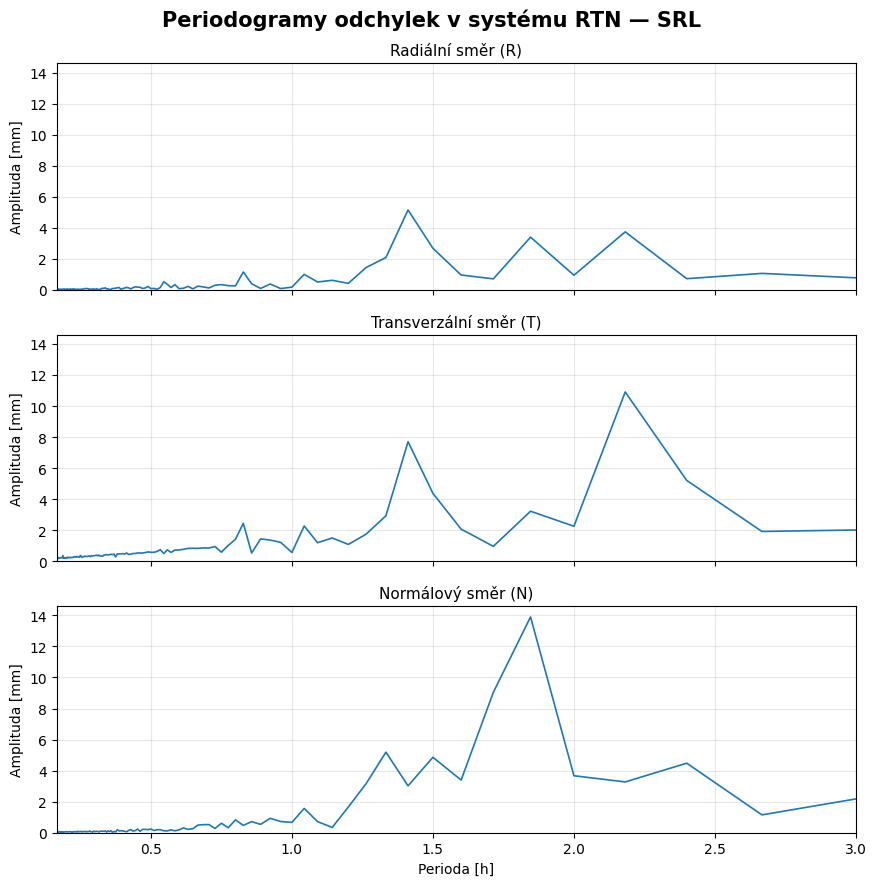

In [11]:
df = clean_df.copy()

t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

MIN_PERIOD_S = 10 * 60
MAX_PERIOD_S = 3 * 3600

periodograms = {}
global_max = 0

for col, _ in components:
    pgram = compute_periodogram(
        t, df[col].values,
        method="fft",
        min_period=MIN_PERIOD_S,
        max_period=MAX_PERIOD_S,
    )
    periodograms[col] = pgram
    local_max = pgram.loc[pgram["period"] / 3600 > 0.5, "amplitude"].max()
    if local_max > global_max:
        global_max = local_max

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, (col, title) in zip(axes, components):
    pgram = periodograms[col]
    periods_h = pgram["period"] / 3600
    ax.plot(periods_h, pgram["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(MIN_PERIOD_S / 3600, MAX_PERIOD_S / 3600)
fig.suptitle(f"Periodogramy odchylek v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_periodograms_fft"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Daily RTN RMS over time

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001-doy030_daily_rtn_rms  [.pdf + .png]


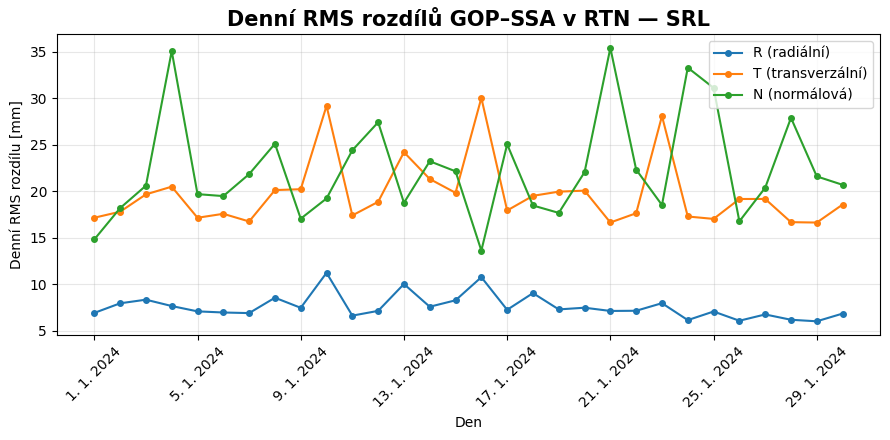

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["R_rms"] * 1000, "o-", color="C0", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day"], plot_df["T_rms"] * 1000, "o-", color="C1", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day"], plot_df["N_rms"] * 1000, "o-", color="C2", linewidth=1.5, markersize=4, label="N (normálová)")

ax.set_xlabel("Den")
ax.set_ylabel("Denní RMS rozdílu [mm]")
ax.set_title(f"Denní RMS rozdílů {_sol_display} v RTN — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_rtn_rms"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Daily 3D RMS over time

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001-doy030_daily_3d_rms  [.pdf + .png]


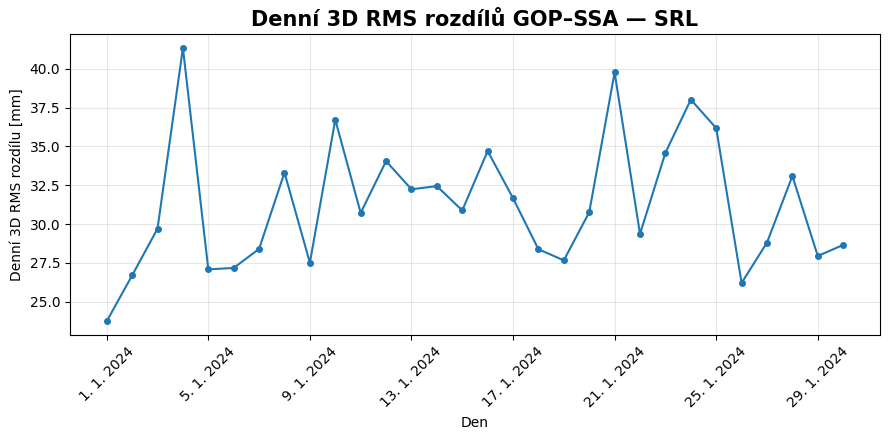

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["3D_rms"] * 1000, "o-", linewidth=1.5, markersize=4)

ax.set_xlabel("Den")
ax.set_ylabel("Denní 3D RMS rozdílu [mm]")
ax.set_title(f"Denní 3D RMS rozdílů {_sol_display} — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_3d_rms"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001-doy030_daily_rtn_3d_rms  [.pdf + .png]


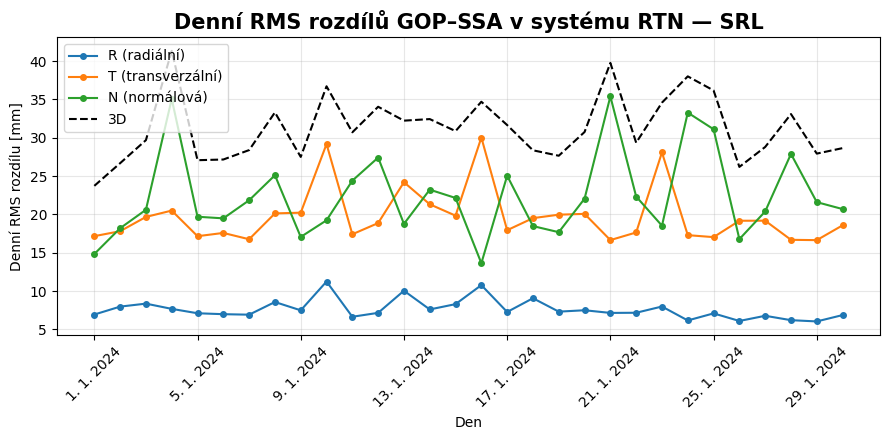

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["R_rms"] * 1000, "o-", color="C0", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day"], plot_df["T_rms"] * 1000, "o-", color="C1", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day"], plot_df["N_rms"] * 1000, "o-", color="C2", linewidth=1.5, markersize=4, label="N (normálová)")
ax.plot(plot_df["day"], plot_df["3D_rms"] * 1000, "k--", linewidth=1.5, markersize=4, label="3D")

ax.set_xlabel("Den")
ax.set_ylabel("Denní RMS rozdílu [mm]")
ax.set_title(f"Denní RMS rozdílů {_sol_display} v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_rtn_3d_rms"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Daily RTN mean differences

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001-doy030_daily_rtn_mean  [.pdf + .png]


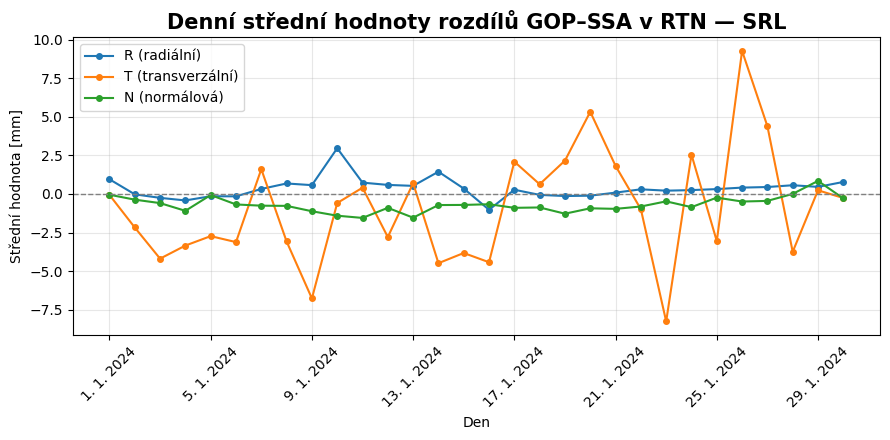

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["R_mean"] * 1000, "o-", color="C0", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day"], plot_df["T_mean"] * 1000, "o-", color="C1", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day"], plot_df["N_mean"] * 1000, "o-", color="C2", linewidth=1.5, markersize=4, label="N (normálová)")

ax.axhline(0.0, color="gray", linewidth=1.0, linestyle="--")
ax.set_xlabel("Den")
ax.set_ylabel("Střední hodnota [mm]")
ax.set_title(f"Denní střední hodnoty rozdílů {_sol_display} v RTN — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_rtn_mean"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Daily RMS vs RMS0

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001-doy030_daily_3d_rms_vs_rms0  [.pdf + .png]


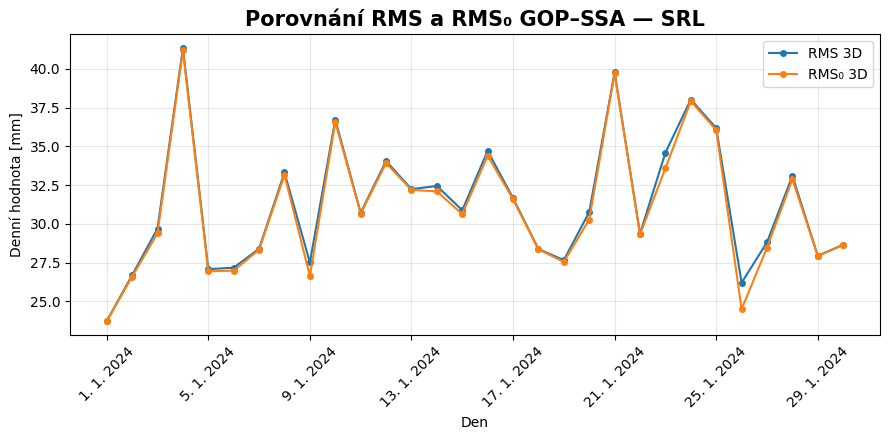

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["3D_rms"]  * 1000, "o-", linewidth=1.5, markersize=4, label="RMS 3D")
ax.plot(plot_df["day"], plot_df["3D_rms0"] * 1000, "o-", linewidth=1.5, markersize=4, label="RMS₀ 3D")

ax.set_xlabel("Den")
ax.set_ylabel("Denní hodnota [mm]")
ax.set_title(f"Porovnání RMS a RMS₀ {_sol_display} — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_3d_rms_vs_rms0"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Statistics for the selected test day

In [17]:
def _rms_col(s): return float((s**2).mean()**0.5)
def _std_col(s): return float(((s - s.mean())**2).mean()**0.5)

day_table = pd.DataFrame({
    "component": ["R", "T", "N", "3D"],
    "mean_mm":   [clean_df["dR"].mean(),    clean_df["dT"].mean(),
                  clean_df["dN"].mean(),    clean_df["d3D"].mean()],
    "std_mm":    [_std_col(clean_df["dR"]), _std_col(clean_df["dT"]),
                  _std_col(clean_df["dN"]), _std_col(clean_df["d3D"])],
    "rms_mm":    [_rms_col(clean_df["dR"]), _rms_col(clean_df["dT"]),
                  _rms_col(clean_df["dN"]), _rms_col(clean_df["d3D"])],
})
display(day_table.round(2))

,component,mean_mm,std_mm,rms_mm
0,R,0.95000,6.88000,6.94000
1,T,-0.07000,17.17000,17.17000
2,N,-0.05000,14.84000,14.84000
3,3D,20.10000,12.62000,23.73000


In [18]:
_day_cols = [
    Col("component", "Složka",                   None),
    Col("mean_mm",   "Střední hodnota [mm]",     2),
    Col("std_mm",    "Směrodatná odchylka [mm]", 2),
    Col("rms_mm",    "RMS [mm]",                 2),
]
_table_path = TABLES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_day_stats.tex"
save_latex_table(
    day_table, _table_path, cols=_day_cols,
    caption=f"Statistiky rozdílů {_sol_display} v RTN pro den {_doy_str} — {_sat_display}",
    label=f"tab:{SOLUTION_TAG}_{satellite}_{_doy_str}_day_stats",
    print_preview=True,
)
print(f"Uloženo: {_table_path}")

\begin{table}[H]
\centering
\caption{Statistiky rozdílů GOP–SSA v RTN pro den doy001 — SRL}
\label{tab:gop_vs_ssa_srl_doy001_day_stats}
\begin{tabular}{lrrr}
\toprule
Složka & Střední hodnota [mm] & Směrodatná odchylka [mm] & RMS [mm] \\
\midrule
R & 0.95 & 6.88 & 6.94 \\
T & -0.07 & 17.17 & 17.17 \\
N & -0.05 & 14.84 & 14.84 \\
3D & 20.10 & 12.62 & 23.73 \\
\bottomrule
\end{tabular}
\end{table}

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001_day_stats.tex


## RMS summary for the full period

In [19]:
_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

rms_table = pd.DataFrame({
    "component": ["R", "T", "N", "3D"],
    "min_mm":    [plot_df["R_rms"].min()  * 1000, plot_df["T_rms"].min()  * 1000,
                  plot_df["N_rms"].min()  * 1000, plot_df["3D_rms"].min() * 1000],
    "mean_mm":   [plot_df["R_rms"].mean() * 1000, plot_df["T_rms"].mean() * 1000,
                  plot_df["N_rms"].mean() * 1000, plot_df["3D_rms"].mean()* 1000],
    "max_mm":    [plot_df["R_rms"].max()  * 1000, plot_df["T_rms"].max()  * 1000,
                  plot_df["N_rms"].max()  * 1000, plot_df["3D_rms"].max() * 1000],
})
display(rms_table.round(2))

,component,min_mm,mean_mm,max_mm
0,R,6.04000,7.62000,11.25000
1,T,16.65000,19.75000,30.04000
2,N,13.64000,22.40000,35.40000
3,3D,23.73000,31.26000,41.34000


In [20]:
_rms_cols = [
    Col("component", "Složka",          None),
    Col("min_mm",    "Min. RMS [mm]",   2),
    Col("mean_mm",   "Prům. RMS [mm]", 2),
    Col("max_mm",    "Max. RMS [mm]",   2),
]
_table_path = TABLES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_rms.tex"
save_latex_table(
    rms_table, _table_path, cols=_rms_cols,
    caption=f"Denní RMS rozdílů {_sol_display} v RTN ({_pd_str}) — {_sat_display}",
    label=f"tab:{SOLUTION_TAG}_{satellite}_{_pd_str}_rms",
    print_preview=True,
)
print(f"Uloženo: {_table_path}")

\begin{table}[H]
\centering
\caption{Denní RMS rozdílů GOP–SSA v RTN (doy001-doy030) — SRL}
\label{tab:gop_vs_ssa_srl_doy001-doy030_rms}
\begin{tabular}{lrrr}
\toprule
Složka & Min. RMS [mm] & Prům. RMS [mm] & Max. RMS [mm] \\
\midrule
R & 6.04 & 7.62 & 11.25 \\
T & 16.65 & 19.75 & 30.04 \\
N & 13.64 & 22.40 & 35.40 \\
3D & 23.73 & 31.26 & 41.34 \\
\bottomrule
\end{tabular}
\end{table}

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\satellites\hermite\srl\gop_vs_ssa_srl_doy001-doy030_rms.tex
